### Interpretability of Random Forests for all regions.

File generated 9/25/2025 (hbd), uploaded into UFS Git 12/3/2025. 

This file works on making the plots for each region based on predictions. 

In [1]:
#relevant import statements
import numpy as np
import math
import pandas as pd
import xarray as xr 
import pickle 
import matplotlib.pyplot as plt


#import seaborn as sns # statistical data visualization

##just to stop the excess number of warnings 
import warnings
warnings.filterwarnings('ignore')

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from geopy.distance import great_circle
import cartopy.crs as ccrs
from matplotlib.path import Path

In [2]:
##import files to make the plots
##data management
from PredictionPlots import extrapolate, daily_anomaly, preprocess_andopen
##plotting
from PredictionPlots import  BWcheckevent_label, CScheckevent_label, BWplot, BWplot_multi, GPH_horzCS

In [3]:
##for horizontal cross sections of GPH
infile = open("../../UFS_metrics/CAP_ERA5_GPH10.p","rb")
gph_input = pickle.load(infile)  ##GPH vertical cross section along longitudes
GPH = gph_input[:, :, 0:10, :, :].reshape((56*10, 26, 180)) 
infile.close()

infile = open("../../UFS_metrics/CAP_ERA5_GPHanoms10.p","rb")
gph_input = pickle.load(infile)  ##GPH vertical cross section along longitudes
GPHA = gph_input[:, :,0:10, :, :].reshape((56*10, 26, 180)) 
infile.close()

print("GPH shape: ",GPH.shape)

GPH shape:  (560, 26, 180)


In [4]:
lat = np.arange(90, 38, -2)
print("Len (90-40) Latitudes: ", len(lat))
lon = np.arange(0, 362, 2)
print("Len longitudes: ", len(lon))
#lev = np.array([1., 2., 3., 5., 7., 10., 20., 30., 50., 70., 100., 125., 150., 175., 200., 225., 250., 300., 350., 400., 
                #450., 500., 550., 600., 650., 700., 750., 775., 800., 825., 850., 875., 900., 925., 950., 975., 1000.])
#print("Len levels: ", len(lev))

Len (90-40) Latitudes:  26
Len longitudes:  181


In [5]:
files = ['ERA5','Prototype5','Prototype6','Prototype7','Prototype8']
region = ['Europe','Canada','SEUS']

Europe
ERA5
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for ERA-5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Europe
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Europe
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype6 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)


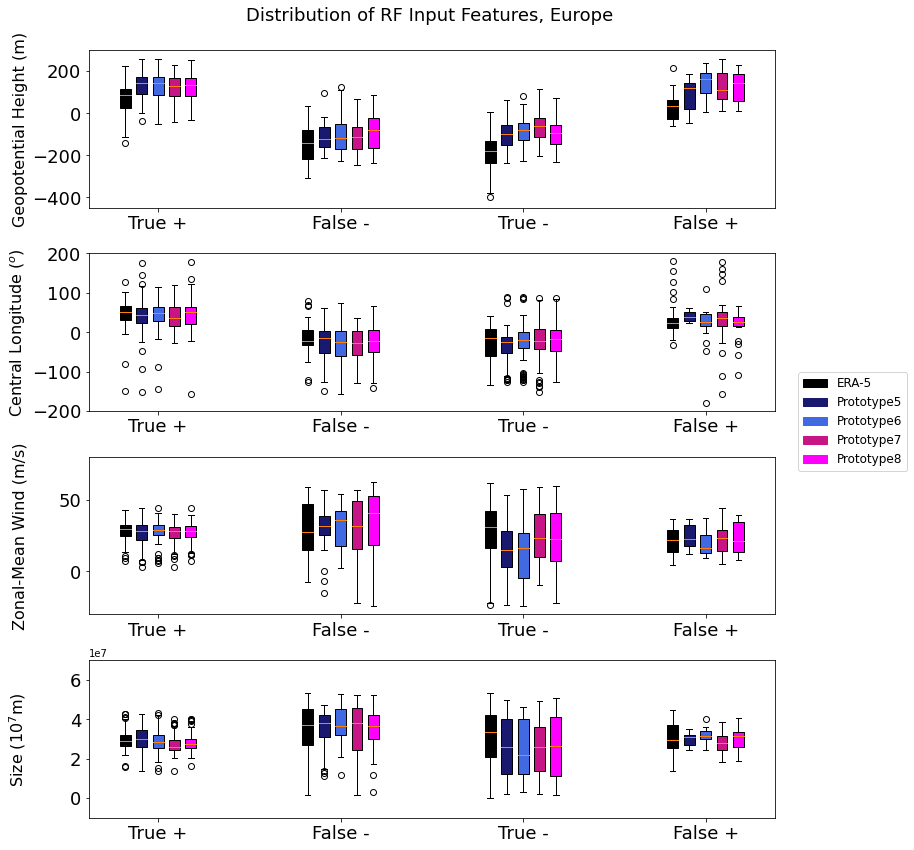

Canada
ERA5
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for ERA-5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Canada
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Canada
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype6 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)


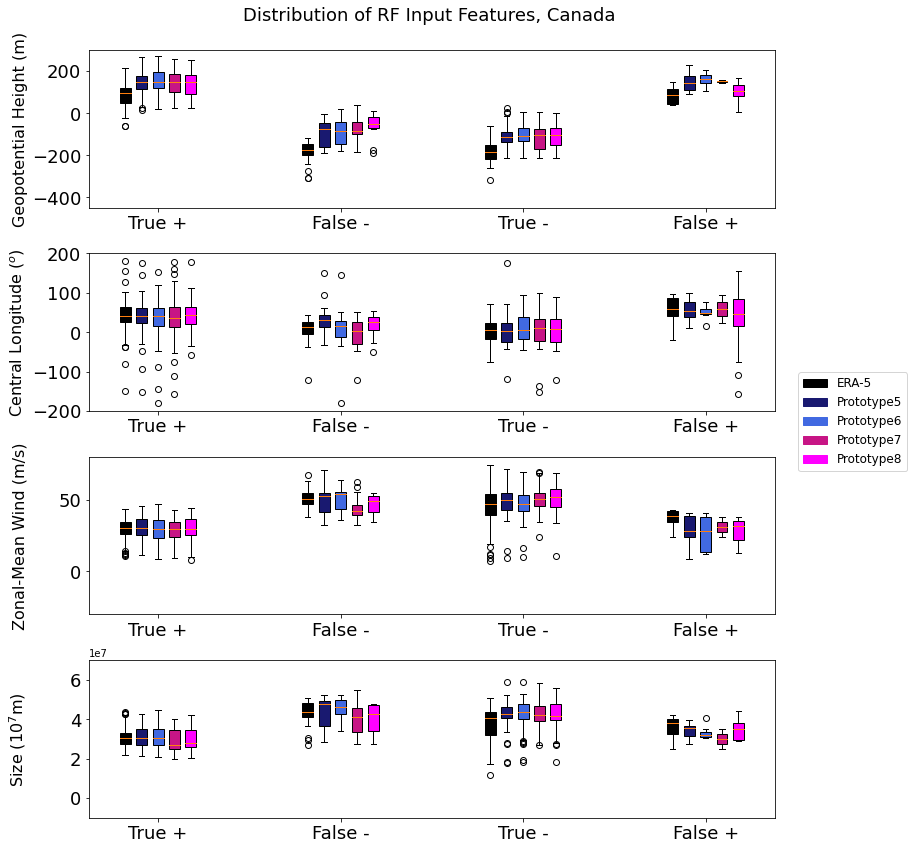

SEUS
ERA5
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for ERA-5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
SEUS
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype5 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checking indices ...
SEUS
UFS
Load data...
Returning final input array.
Opening corresponding temperature data and indices...
Separating indices for Prototype6 ...
Check shape of index array ... (560,)
Checking indices ...
Check shape of index array ... (560,)
Checki

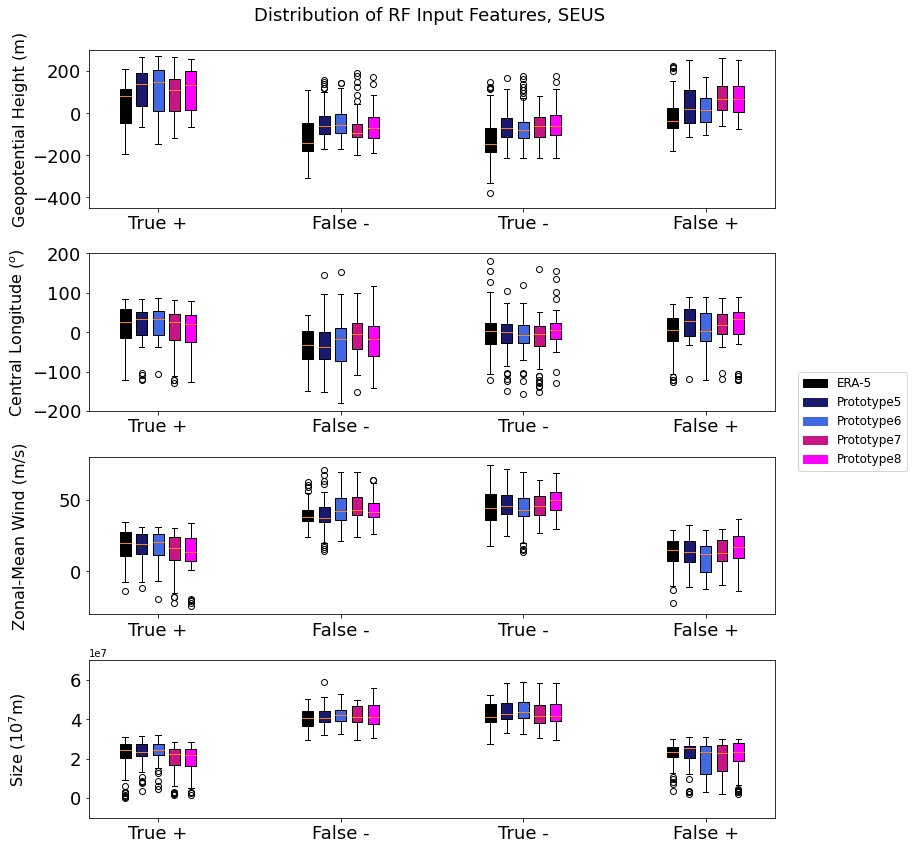

In [6]:
##separate function to do JUST BW plots with all values on the plot
for i in range(len(region)):
    forecast_area = region[i]
    Tpos_dict = {}
    Tneg_dict = {}
    Fpos_dict = {}
    Fneg_dict = {}

    for j in range(len(files)):

        region_file = f'{forecast_area}_{files[j]}'
        if files[j] == 'ERA5':
            ufs_index = " "
            model_name = 'ERA-5'
            input_data, output_data, metrics, pos, Fpos, neg, Fneg = preprocess_andopen(forecast_area, "ERA5", ufs_index, region_file)

        else:
            ufs_index = j - 1
            model_name = files[j] #P5, P6, P7, P8
            input_data, output_data, metrics, pos, Fpos, neg, Fneg = preprocess_andopen(forecast_area, "UFS", ufs_index, region_file)

        print(f"Separating indices for {model_name} ...")
        BW_pos  = BWcheckevent_label(pos,  input_data)
        BW_neg  = BWcheckevent_label(neg,  input_data)
        BW_Fpos = BWcheckevent_label(Fpos, input_data)
        BW_Fneg = BWcheckevent_label(Fneg, input_data)

        #dictionary
        Tpos_dict[model_name] = BW_pos
        Tneg_dict[model_name] = BW_neg
        Fpos_dict[model_name] = BW_Fpos
        Fneg_dict[model_name] = BW_Fneg
    print(f"Plotting combined BW plot for {forecast_area} ...")
    BWplot_multi(Tpos_dict,Tneg_dict,Fpos_dict,Fneg_dict,metrics,f'{forecast_area}',f'./images/composite/BW/MULTI_BW_{forecast_area}')